In [1]:
import os
import decode
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

start_iter = 200 
end_iter = 700
frames_per_iter = 250

out_path = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2'
out_csv = os.path.join(out_path, f'emitters_{start_iter}_{end_iter}_filtered.csv')
h5s_path = os.path.join(out_path, f'processed-2025-06-27')

c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
start_frame = start_iter * frames_per_iter
end_frame = (end_iter+1) * frames_per_iter

#hesslab_input_file =  r'C:\Users\bnort\work\Janelia_slm\data\James processing ASCII and RAW Data files\2h - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_PALM_LOCALIZATIONS_WITH_BOTH_XY_AND_Z_DRIFT_CORRECTION_ASCII.txt.hdf5'
hesslab_input_file = r'C:\Users\bnort\work\Janelia_slm\data\James processing ASCII and RAW Data files\2a - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_with_winding_file_RAW_UNPROCESSED_PALM_LOCALIZATIONS_ASCII.hdf5'
#hesslab_input_file = r'/home/bnorthan/janelia_slm/data/Janelia_PALM_RUN2/IDL Peak Finder/2a - PALM_Run2_Slab_0001_488nm_constrained_Gaussian_fitting_gauss_half_width_3_with_winding_file_RAW_UNPROCESSED_PALM_LOCALIZATIONS_ASCII.hdf5'
emitters=decode.EmitterSet.load(hesslab_input_file)
# filter based on start and end frame
emitters = emitters[(emitters.frame_ix >= start_frame) & (emitters.frame_ix < end_frame)]
print('Hesslab Emitters',emitters)



Hesslab Emitters EmitterSet
::num emitters: 15960656
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50000 - 175249
::spanned volume: [ 8.84620e-01  5.71193e-01 -8.00000e+02] - [800.    798.679 599.999]


C:\Users\bnort\AppData\Local\Temp\ipykernel_12768\3538920061.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_12768\3538920061.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::su

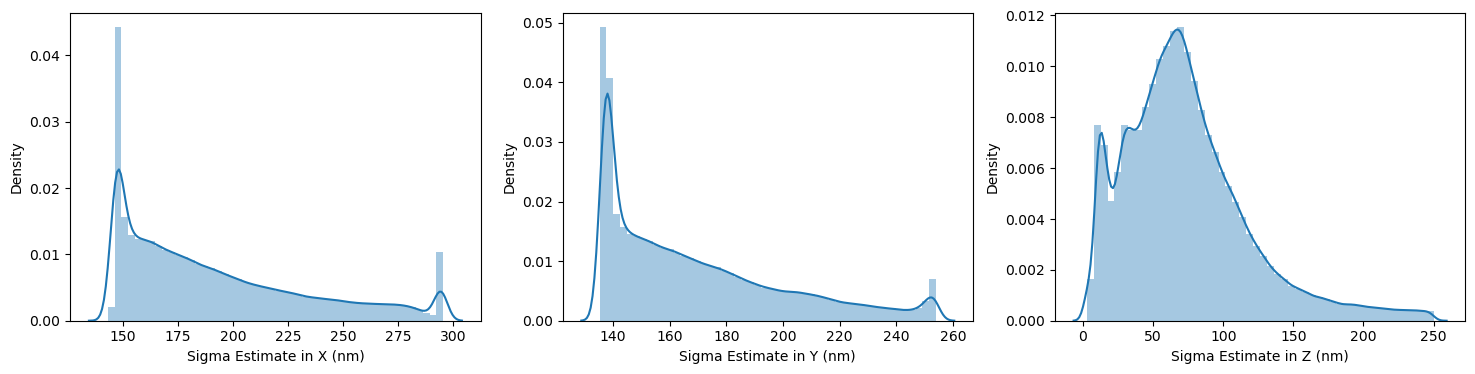

In [3]:
sub_sample = 25

plt.figure(figsize=(18,4))
plt.subplot(131)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
plt.xlabel('Sigma Estimate in X (nm)')

plt.subplot(132)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 1].numpy())
plt.xlabel('Sigma Estimate in Y (nm)')

plt.subplot(133)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 2].numpy())
plt.xlabel('Sigma Estimate in Z (nm)')

plt.show()

C:\Users\bnort\AppData\Local\Temp\ipykernel_12768\686117783.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.phot[::sub_sample].numpy())


Text(0.5, 0, 'Sigma Estimate in X (nm)')

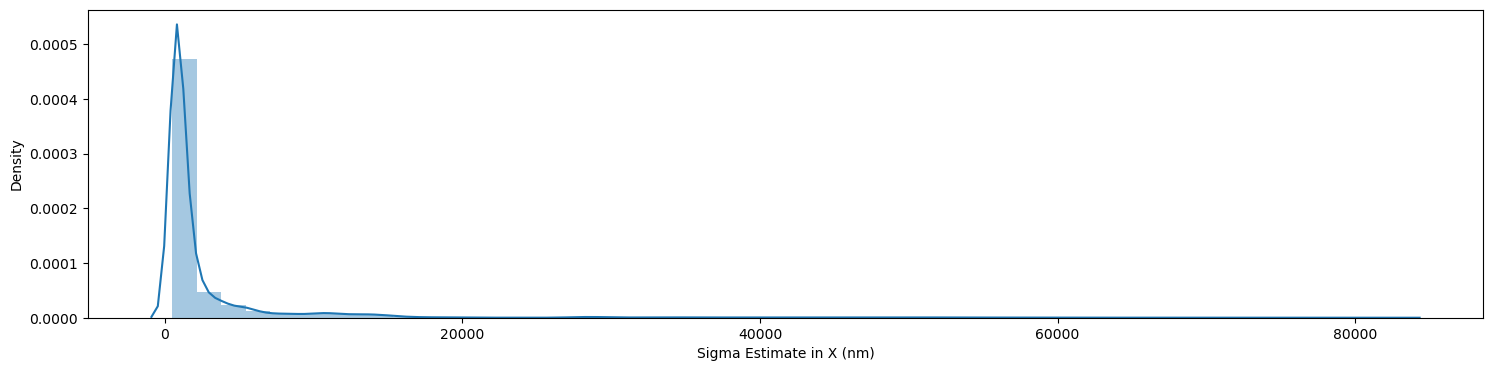

In [4]:
sub_sample = 25

plt.figure(figsize=(18,4))
sns.distplot(emitters.phot[::sub_sample].numpy())
plt.xlabel('Sigma Estimate in X (nm)')



In [7]:
print(emitters)

EmitterSet
::num emitters: 15960656
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50000 - 175249
::spanned volume: [ 8.84620e-01  5.71193e-01 -8.00000e+02] - [800.    798.679 599.999]


In [8]:
print(emitters)
sigma_x_high_threshold = 250
sigma_y_high_threshold = 250
sigma_z_high_threshold = 100
prob_threshold = 0.0
phot_lower_threshold = 5000
coord_limit=((500,700),(100,200))
coord_limit=((0,500),(0,700))

print("0,1", coord_limit[0][0], coord_limit[0][1])

emitters_filtered = emitters[
    (emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitters.prob >= prob_threshold)
    * (emitters.phot >= phot_lower_threshold)
    
    ]

print(emitters_filtered)

'''
emitters_filtered = emitters_filtered[
    (emitters_filtered.xyz_px[:, 0]>= 300) & (emitters_filtered.xyz_px[:, 0] <= 360) &
    (emitters_filtered.xyz_px[:, 1]>= 500) & (emitters_filtered.xyz_px[:, 1] <= 800) 
    #(emitters_filtered.frame_ix==29)
]
'''

emitters_filtered = emitters_filtered[
    (emitters_filtered.xyz_px[:, 0]>= 380) & (emitters_filtered.xyz_px[:, 0] <= 480) &
    (emitters_filtered.xyz_px[:, 1]>= 500) & (emitters_filtered.xyz_px[:, 1] <= 800) 
    #(emitters_filtered.frame_ix==29)
]
print(emitters_filtered)





EmitterSet
::num emitters: 15960656
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50000 - 175249
::spanned volume: [ 8.84620e-01  5.71193e-01 -8.00000e+02] - [800.    798.679 599.999]
0,1 0 500
EmitterSet
::num emitters: 1249307
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50000 - 175249
::spanned volume: [ 115.653    23.3083 -391.213 ] - [799.104 696.816 469.404]
EmitterSet
::num emitters: 61633
::xy unit: px
::px size: tensor([130., 130.])
::frame range: 50001 - 175249
::spanned volume: [404.37   544.142   39.6808] - [405.569 553.113 469.378]


In [9]:
def render_emitters(emitters):

    fig, axs = plt.subplots(1, 1, figsize=(24, 12))

    px_size = 130.

    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-1000, 1000], colextent=[-1000, 1000], plot_axis=(0, 1),
                            contrast=15.25).render(emitters, emitters.xyz_nm[:, 2], ax=axs)

    '''
    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], plot_axis=(0, 2)).render(emitters, ax=axs[1, 0])

    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 1),
                            contrast=1.25).render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[0, 1])

    decode.renderer.Renderer2D(px_size=px_size, sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 2)).\
        render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[1, 1])
    '''
    #plt.savefig(os.path.join(fig_path, rf'fitting\rendered.png'), dpi=300, bbox_inches='tight')
    #plt.show()

    return fig

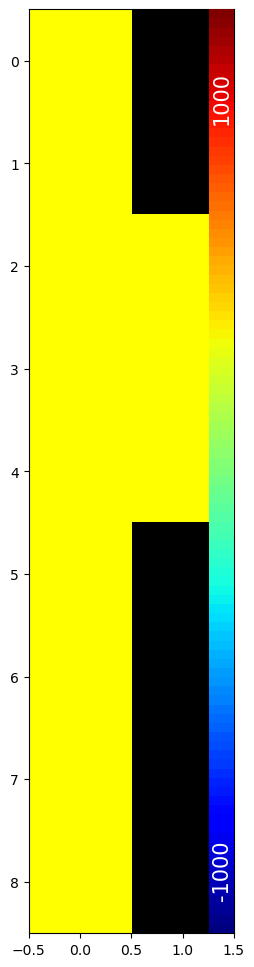

In [10]:

fig = render_emitters(emitters_filtered)

In [11]:
from wip_util import get_np_points
bead_points = get_np_points(emitters_filtered, 0, 10000000, True)

bead_points_ = bead_points[:, 0:4]

bead_points.shape, bead_points_.shape

((61633, 4), (61633, 4))

In [12]:
emitters_filtered.frame_ix.min(), emitters_filtered.frame_ix.max()

(tensor(50001), tensor(175249))

In [13]:
bead_points.shape, bead_points[:,0].min(), bead_points_[:,0].max()

bead_points[:100]

array([[50001.   ,   404.991,   544.282,   355.855],
       [50011.   ,   404.97 ,   544.238,   298.358],
       [50026.   ,   405.022,   544.259,   313.869],
       [50027.   ,   404.962,   544.212,   377.225],
       [50048.   ,   404.989,   544.277,   399.899],
       [50053.   ,   405.012,   544.225,   349.48 ],
       [50055.   ,   404.972,   544.272,   324.781],
       [50056.   ,   404.969,   544.236,   314.816],
       [50069.   ,   405.001,   544.272,   373.421],
       [50073.   ,   404.988,   544.273,   379.845],
       [50075.   ,   405.007,   544.18 ,   356.681],
       [50078.   ,   405.011,   544.234,   395.336],
       [50080.   ,   405.013,   544.159,   405.96 ],
       [50082.   ,   405.   ,   544.307,   332.726],
       [50095.   ,   405.018,   544.303,   325.673],
       [50102.   ,   404.995,   544.232,   329.908],
       [50104.   ,   404.965,   544.235,   341.445],
       [50112.   ,   404.957,   544.191,   320.267],
       [50115.   ,   405.043,   544.307,   402

(61633, 4)


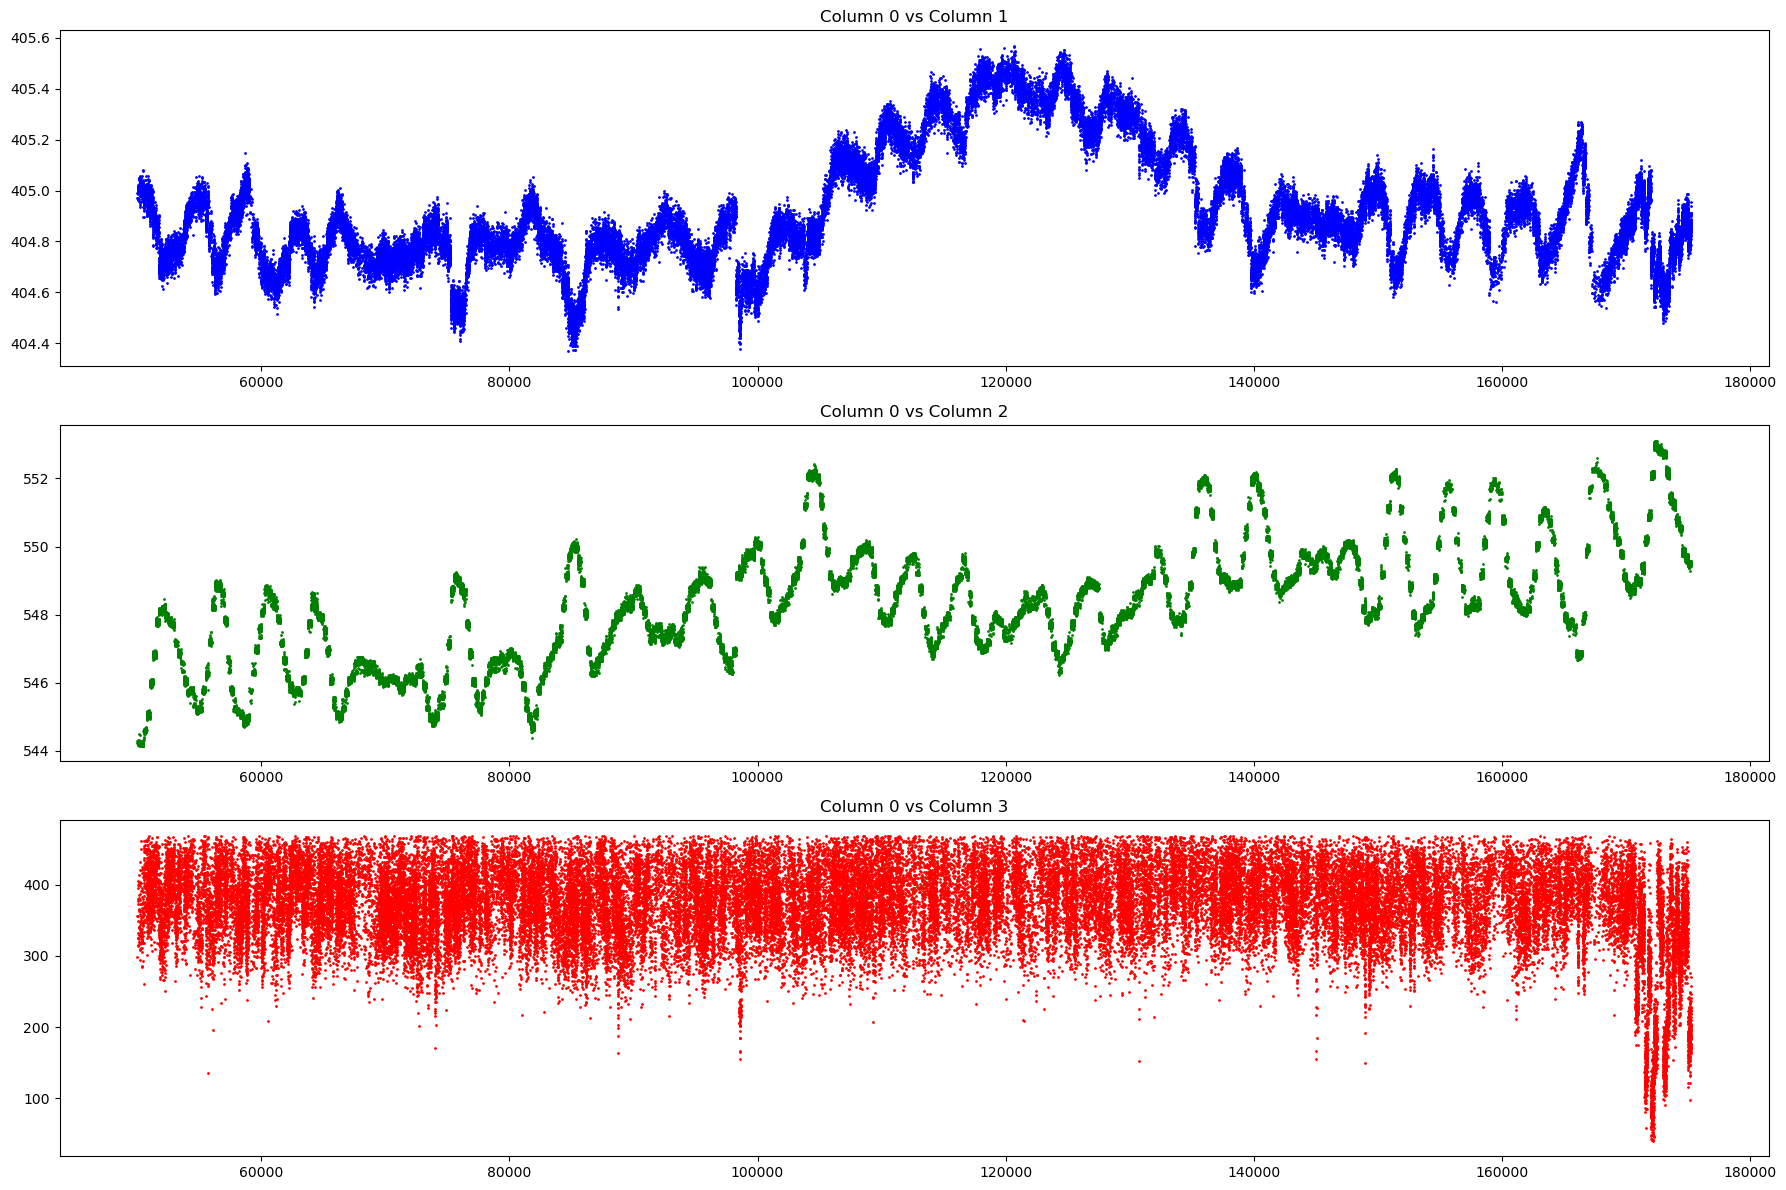

In [15]:
import matplotlib.pyplot as plt

bead_points_ = bead_points[:, 0:4]  # Assuming we want to plot the first four columns
# bead_points_ has shape (N, M) where columns are features
print(bead_points_.shape)

fig, axes = plt.subplots(3, 1, figsize=(18, 12))  # 1 row, 3 columns

# Plot column 0 vs column 1
axes[0].scatter(bead_points_[:, 0], bead_points_[:, 1], s=1, color='blue')
axes[0].set_title('Column 0 vs Column 1')

# Plot column 0 vs column 2
axes[1].scatter(bead_points_[:, 0], bead_points_[:, 2], s=1, color='green')
axes[1].set_title('Column 0 vs Column 2')

# Plot column 0 vs column 3
axes[2].scatter(bead_points_[:, 0], bead_points_[:, 3], s=1, color='red')
axes[2].set_title('Column 0 vs Column 3')

plt.tight_layout()
plt.show()